<a href="https://colab.research.google.com/github/amirf95/Image-processing/blob/hmw1/aii419_lab01_getting_started.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AII419 – Image Processing
## Lab 1: Getting Started with Image Processing (Python + OpenCV)

**Duration:** 2–3 hours  
**Objectives:**
- Set up Python and required libraries (OpenCV, NumPy, Matplotlib).
- Load, display, and save images.
- Explore image metadata (shape, dtype, channels, min/max).
- Practice basic conversions (RGB↔Gray, BGR note), and simple pixel operations.
- Build confidence writing reproducible lab code and a short report.

**Provided Assets:** `assets/checkerboard.png`, `assets/gradient.png`, `assets/circles.png`  
(You may also use your own photos.)

---


## 1) Environment Setup

Install (once):
```bash
pip install opencv-python numpy matplotlib
```
> **Note:** OpenCV reads images as **BGR** by default; convert to RGB for Matplotlib.


## 2) Starter Code: Imports and Utilities

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Helper to show BGR images correctly with Matplotlib (which expects RGB)
def bgr2rgb(img_bgr):
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

ASSETS = Path('assets')
list(ASSETS.iterdir()) if ASSETS.exists() else []


[PosixPath('assets/checkerboard.png'),
 PosixPath('assets/circles.png'),
 PosixPath('assets/gradient.png')]

## 3) Task 1 — Load & Display Images (5 pts)
1. Load `assets/checkerboard.png`, `assets/gradient.png`, and `assets/circles.png` with OpenCV.  
2. Display each image with Matplotlib (`plt.imshow()`) in this notebook.  
3. Print for each image: **shape**, **dtype**, **min/max** pixel values.


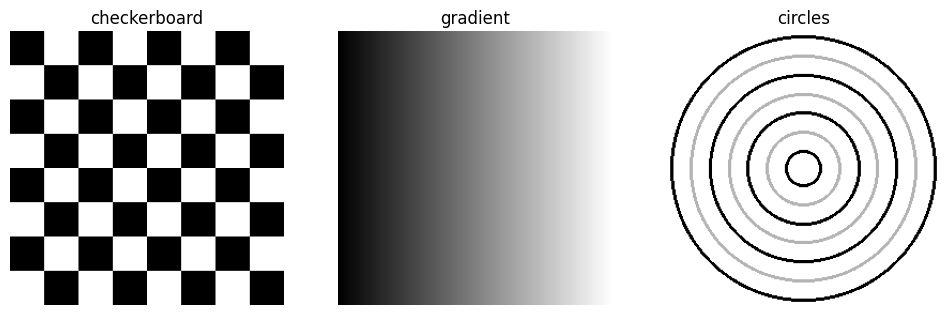

checkerboard: shape=(256, 256), dtype=uint8, min=0, max=255
gradient: shape=(256, 256), dtype=uint8, min=0, max=255
circles: shape=(256, 256), dtype=uint8, min=0, max=255


In [ ]:
# Load images in grayscale
img_checker = cv2.imread(str(ASSETS / 'checkerboard.png'), cv2.IMREAD_GRAYSCALE)
img_gradient = cv2.imread(str(ASSETS / 'gradient.png'), cv2.IMREAD_GRAYSCALE)
img_circles  = cv2.imread(str(ASSETS / 'circles.png'), cv2.IMREAD_GRAYSCALE)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img_checker, cmap='gray'); axes[0].set_title('checkerboard'); axes[0].axis('off')
axes[1].imshow(img_gradient, cmap='gray'); axes[1].set_title('gradient'); axes[1].axis('off')
axes[2].imshow(img_circles,  cmap='gray'); axes[2].set_title('circles'); axes[2].axis('off')
plt.show()

for name, img in [('checkerboard', img_checker), ('gradient', img_gradient), ('circles', img_circles)]:
    print(f"{name}: shape={img.shape}, dtype={img.dtype}, min={img.min()}, max={img.max()}")


## 4) Task 2 — Save Variants (5 pts)
1. Convert `checkerboard` to **binary** using Otsu's threshold and save as `outputs/checkerboard_binary.png`.  
2. Normalize `gradient` to [0, 255] and save as `outputs/gradient_norm.png`.  
3. Invert `circles` and save as `outputs/circles_invert.png`.


In [ ]:
from pathlib import Path
OUT = Path('outputs'); OUT.mkdir(exist_ok=True)

# 1) Otsu threshold
_, checker_bin = cv2.threshold(img_checker, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
cv2.imwrite(str(OUT / 'checkerboard_binary.png'), checker_bin)

# 2) Normalize gradient
grad_norm = cv2.normalize(img_gradient, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)
cv2.imwrite(str(OUT / 'gradient_norm.png'), grad_norm)

# 3) Invert circles
circles_inv = 255 - img_circles
cv2.imwrite(str(OUT / 'circles_invert.png'), circles_inv)

print('Saved to:', list(OUT.iterdir()))


Saved to: [PosixPath('outputs/circles_invert.png'), PosixPath('outputs/gradient_norm.png'), PosixPath('outputs/checkerboard_binary.png')]


## 5) Task 3 — Color, Channels, and Conversions (10 pts)
1. Convert `circles` (grayscale) to **BGR** by stacking channels.  
2. Draw a **blue** rectangle and a **red** circle on a copy.  
3. Convert to **HSV** and visualize H, S, V channels.


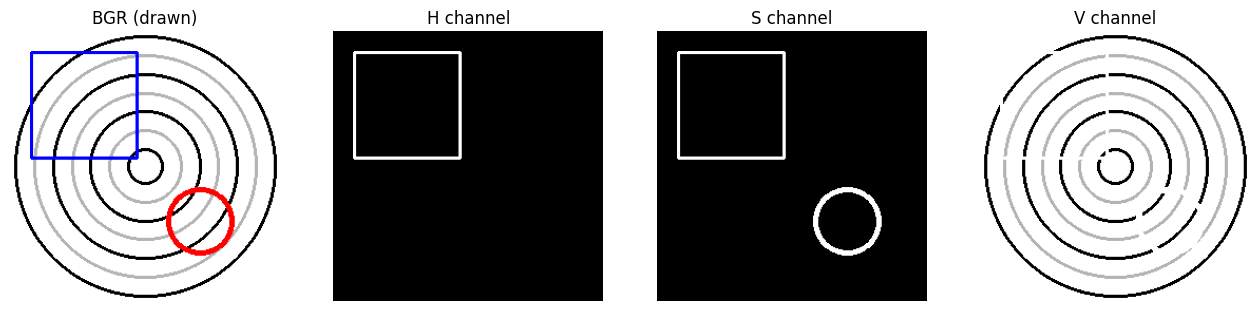

In [ ]:
circles_bgr = cv2.cvtColor(img_circles, cv2.COLOR_GRAY2BGR)

circles_draw = circles_bgr.copy()
cv2.rectangle(circles_draw, (20, 20), (120, 120), (255, 0, 0), 2)  # Blue rectangle (BGR)
cv2.circle(circles_draw, (180, 180), 30, (0, 0, 255), 3)          # Red circle

circles_hsv = cv2.cvtColor(circles_draw, cv2.COLOR_BGR2HSV)
H, S, V = cv2.split(circles_hsv)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(bgr2rgb(circles_draw)); axes[0].set_title('BGR (drawn)'); axes[0].axis('off')
axes[1].imshow(H, cmap='gray'); axes[1].set_title('H channel'); axes[1].axis('off')
axes[2].imshow(S, cmap='gray'); axes[2].set_title('S channel'); axes[2].axis('off')
axes[3].imshow(V, cmap='gray'); axes[3].set_title('V channel'); axes[3].axis('off')
plt.show()


## 6) Task 4 — Report Questions (10 pts)
Answer briefly (3–5 sentences each):  
1. `cv2.imshow` vs Matplotlib displays?  
2. Why BGR in OpenCV and what happens if you forget RGB conversion?  
3. Compare histograms of `gradient.png` and `checkerboard.png`.  
4. When does Otsu work well, and when might fixed thresholding fail?


# Answer


1. ### cv2.imshow vs Matplotlib displays?

cv2.imshow opens diretly a new window while running the code creating a new GUI, which is good for real life implementation but it may cause Gooogle Colab to crash buecause it cna t open  an external GUI windoow.
While Matplotlib render the execution directly in the notebook's cell thus matplotlib is prefered for the documentation and notebooks perposes.


2. ###  Why BGR in OpenCV and what happens if you forget RGB conversion?
OpenCV uses BGR (Blue-Green-Red) because that was the standard for camera manufacturers and software developers when the library was first created in the 1990s. If you forget to convert to RGB before displaying an image with a standard tool like Matplotlib, the color channels will be swapped. This results in a "color-inverted" look where skin tones appear blue and blue skies appear orange or red.

3. ###  Compare histograms of gradient.png and checkerboard.png.

The histogram for gradient.png shows a broad, continuous distribution of intensities across the x-axis, representing the smooth transition between shades of the grey scale.
 In contrast, the histogram for checkerboard.png  show two distinct, sharp spikes (bimodal) representing the high concentration of pure black and pure white pixels. While the gradient shows a "slope" of data, the checkerboard shows two "towers" with very little data in the mid-tones.

4. ##  When does Otsu work well, and when might fixed thresholding fail?

  Otsu’s method performs best on images with a clear bimodal histogram, where the foreground and background intensities are distinct.
  Fixed thresholding can fail under variable lighting or when the image lacks strong contrast between object and background.


## (Optional Bonus, +5 pts) — Tiny Image Dataset Explorer
- Load all `.png` files in `assets/` and show a thumbnail gallery.
- Compute mean/std intensities and make a simple bar plot.


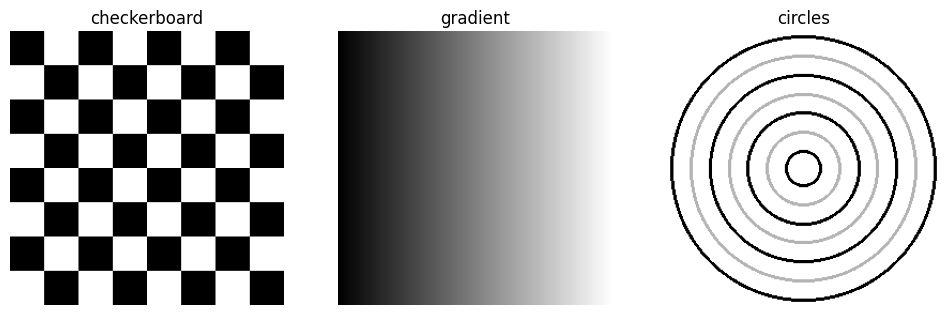

Image 1:
  Mean intensity: 127.5
  Standard deviation: 127.5

Image 2:
  Mean intensity: 127.5
  Standard deviation: 73.90027063549903

Image 3:
  Mean intensity: 230.99945068359375
  Standard deviation: 69.05019642378359



In [ ]:
img_checker = cv2.imread(str(ASSETS / 'checkerboard.png'), cv2.IMREAD_GRAYSCALE)
img_gradient = cv2.imread(str(ASSETS / 'gradient.png'), cv2.IMREAD_GRAYSCALE)
img_circles  = cv2.imread(str(ASSETS / 'circles.png'), cv2.IMREAD_GRAYSCALE)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img_checker, cmap='gray'); axes[0].set_title('checkerboard'); axes[0].axis('off')
axes[1].imshow(img_gradient, cmap='gray'); axes[1].set_title('gradient'); axes[1].axis('off')
axes[2].imshow(img_circles,  cmap='gray'); axes[2].set_title('circles'); axes[2].axis('off')
plt.show()

img = cv2.imread(str(ASSETS / 'checkerboard.png'), cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread(str(ASSETS / 'gradient.png'), cv2.IMREAD_GRAYSCALE)
img3 = cv2.imread(str(ASSETS / 'circles.png'), cv2.IMREAD_GRAYSCALE)

for i, image in enumerate([img, img2, img3], start=1):
    mean, stddev = cv2.meanStdDev(image)
    print(f"Image {i}:")
    print("  Mean intensity:", mean[0][0])
    print("  Standard deviation:", stddev[0][0])
    print()

---

## ✅ Deliverables & Grading (Total: 30 pts + 5 bonus)
- Task 1: 5 pts  
- Task 2: 5 pts  
- Task 3: 10 pts  
- Task 4: 10 pts  
- Bonus: +5 pts

**Submission:** upload `.ipynb` and `outputs/` to LMS (zip as `AII419_Lab01_<StudentID>.zip`).
